<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 10px;">
    <h1 style="color:#e2b96f; font-family:'Segoe UI', sans-serif; font-size:2.2em; margin:0 0 8px 0;">
        Chatbots e Introdução ao ML
    </h1>
    <h2 style="color:#a8d8ea; font-family:'Segoe UI', sans-serif; font-size:1.3em; margin:0 0 6px 0; font-weight:400;">
        Aula 01 — Do "Olá Mundo" ao Aprendizado de Máquina
    </h2>
    <h3 style="color:#e2b96f; font-family:'Segoe UI', sans-serif; font-size:1.05em; margin:0 0 12px 0; font-weight:500;">
        Teoria e Prática — Chatbots por Regras, NLU e ML
    </h3>
    <p style="color:#ccc; font-family:'Segoe UI', sans-serif; font-size:0.9em; margin:0;">
        Prof. Felipe Amaral
    </p>
</div>

<div style="display:flex; gap:10px; margin-top:10px; flex-wrap:wrap;">
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">FIAP</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">Python 3</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">NLP & Machine Learning</span>
</div>

## Mapa da Aula

> **Como usar este notebook:** leia os textos explicativos, **execute cada célula de código** (Shift+Enter), observe os resultados e responda as perguntas de reflexão. Não pule células!

---

### O que você vai aprender hoje?

| # | Tópico | O que vai saber fazer |
|---|--------|-----------------------|
| **1** | **O que é um Chatbot?** | Definir e diferenciar tipos de chatbots |
| **2** | **Chatbot baseado em Regras** | Implementar um ELIZA do zero em Python |
| **3** | **Por que precisamos de ML?** | Identificar as limitações de regras manuais |
| **4** | **Arquitetura de Chatbots** | Entender o fluxo NLU → Diálogo → Resposta |
| **5** | **NLU com Machine Learning** | Treinar um classificador de intenções real |
| **6** | **NLP com NLTK** | Usar uma lib profissional para processar texto |
| **7** | **KPIs do Chatbot** | Medir e monitorar a performance em produção |
| **8** | **Exercícios Práticos** | Implementar e expandir o chatbot por conta própria |


---

## Configuração — Execute esta célula antes de começar

In [1]:
import re
import random
import json
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Optional, List

# Visualização
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# NLP e Machine Learning
import nltk
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Configurações de visualização
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid", palette="muted")

# Baixar recursos do NLTK (só precisa rodar uma vez)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('rslp', quiet=True)   # stemmer para português

print("Todas as bibliotecas carregadas com sucesso!")
print(f"   • NumPy  {np.__version__}")
print(f"   • NLTK   {nltk.__version__}")
import sklearn; print(f"   • Scikit-learn {sklearn.__version__}")

Todas as bibliotecas carregadas com sucesso!
   • NumPy  2.0.2
   • NLTK   3.9.1
   • Scikit-learn 1.6.1


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;">
        <div>
            <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 1</span>
            <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">O que é um Chatbot?</h2>
            <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Antes de construir, precisamos entender o que estamos construindo."</p>
        </div>
    </div>
</div>

### Definição simples

> Um **chatbot** é um programa de computador que conversa com pessoas usando linguagem natural — texto ou voz.

Pensa assim: quando você manda mensagem para o atendimento do banco pelo aplicativo e recebe respostas automáticas, quem está respondendo é um chatbot!

---

### Como chegamos até aqui? — Linha do Tempo

```
1950          1966          1995          2011          2016          2022
  │             │             │             │             │             │
  ▼             ▼             ▼             ▼             ▼             ▼
[Turing]    [ELIZA]       [ALICE]       [Siri]      [Telegram    [ChatGPT]
 Propõe o   Primeiro      Padrões       Apple        Bots]        LLMs mudam
 Teste de   chatbot       AIML          lança        APIs          tudo
 Turing     (regras)      XML           assistente   abertas
```

| Era | Tecnologia | Exemplo | Limitação |
|-----|-----------|---------|-----------|
| **Regras (1960-2000)** | `if/else`, regex | ELIZA | Frágil fora do script |
| **ML Supervisionado (2000-2020)** | Classificadores, NLU | Watson, Dialogflow | Precisa de dados rotulados |
| **LLMs (2022+)** | Transformers bilionários | ChatGPT, Claude | Custo, alucinações |

---

### Os 3 tipos de chatbot que você precisa conhecer

<div style="display:flex; gap:20px; flex-wrap:wrap; margin:16px 0;">
<div style="flex:1; min-width:200px; background:#e3f2fd; border-radius:10px; padding:16px; border-top:4px solid #1565c0;">
<strong>Baseado em Regras</strong><br><br>
Funciona como um <em>fluxograma</em>:<br>
SE usuário diz X → responde Y<br><br>
Simples e previsível<br>
Não entende variações
</div>
<div style="flex:1; min-width:200px; background:#f3e5f5; border-radius:10px; padding:16px; border-top:4px solid #6a1b9a;">
<strong>Baseado em ML</strong><br><br>
<em>Aprende com exemplos</em> e classifica<br>
a intenção do usuário<br><br>
Entende variações de linguagem<br>
Precisa de dados para treinar
</div>
<div style="flex:1; min-width:200px; background:#fff3e0; border-radius:10px; padding:16px; border-top:4px solid #e65100;">
<strong>LLMs (IA Generativa)</strong><br><br>
Modelo treinado em <em>bilhões de textos</em>,<br>
gera respostas livres<br><br>
Fluência impressionante<br>
Custo alto, pode "alucinar"
</div>
</div>

---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;">
        <div>
            <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 2</span>
            <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Chatbot Baseado em Regras</h2>
            <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"O ELIZA — o avô de todos os chatbots."</p>
        </div>
    </div>
</div>

### O ELIZA — o avô de todos os chatbots

Em 1966, Joseph Weizenbaum criou o **ELIZA** no MIT. Era um programa simples que usava **substituição de padrões** para simular um psicoterapeuta. As pessoas ficavam tão impressionadas que acreditavam estar falando com um humano!

**Como funciona?**

```
Usuário: "Eu me sinto triste"
          ↓
    ELIZA procura padrão: "eu me sinto ___"
          ↓
    Substitui: "Por que você se sente triste?"
```

É basicamente um jogo de **localizar e substituir** — sem nenhuma "inteligência" real.

### Vamos implementar nosso próprio ELIZA!

In [2]:
# ELIZA: Chatbot Baseado em Regras
#
# Conceito: usamos EXPRESSÕES REGULARES (regex) para detectar
# padrões na frase do usuário e gerar uma resposta a partir deles.
#
# Uma regex é uma "receita" para encontrar padrões em texto:
#   r"eu me sinto (.+)"  →  encontra "eu me sinto" + qualquer coisa
#   (.+) é um GRUPO DE CAPTURA — guarda o que veio depois
# ============================================================

import re
import random

# PASSO 1: Definir as regras
# Cada regra é uma tupla: (PADRÃO, RESPOSTA)
# Quando o padrão casa com a frase do usuário, a resposta é usada.
# A resposta pode ser uma string fixa ou uma FUNÇÃO (lambda)
# que usa o texto capturado pelo grupo (.+)

REGRAS_ELIZA = [
    # Saudações
    (r"\b(oi|olá|ola|hey|bom dia|boa tarde|boa noite)\b",
     "Olá! Fico feliz em conversar. Como você está se sentindo hoje?"),

    # "Eu me sinto X" → pergunta por que
    (r"eu me sinto (.+)",
     lambda m: f"Por que você se sente **{m.group(1)}**?"),

    # "Eu (quero/preciso/gostaria) X"
    (r"eu (quero|preciso|gostaria de) (.+)",
     lambda m: f"Por que você {m.group(1)} {m.group(2)}? Isso é importante para você?"),

    # "Eu estou X"
    (r"eu (estou|tô|to) (.+)",
     lambda m: f"Há quanto tempo você está {m.group(2)}?"),

    # "Meu X é/está Y"
    (r"meu (.+?) (é|está|foi|era) (.+)",
     lambda m: f"Interessante. Conte-me mais sobre seu {m.group(1)}."),

    # "Não consigo X"
    (r"não consigo (.+)",
     lambda m: f"O que especificamente te impede de {m.group(1)}?"),

    # Despedida
    (r"\b(tchau|até logo|adeus|até mais|xau)\b",
     "Foi ótimo conversar! Até a próxima. 👋"),
]

# Respostas genéricas, usadas quando nenhuma regra casa
FALLBACKS = [
    "Isso é muito interessante. Pode me contar mais?",
    "E como isso te faz sentir?",
    "Por que você me conta isso?",
    "Vamos explorar esse pensamento com mais profundidade.",
    "Hmm... Continue.",
]

#  PASSO 2: A função principal do chatbot
def eliza_responder(frase_usuario: str) -> str:
    """
    Recebe a frase do usuário, testa cada regra em ordem,
    e retorna a primeira resposta que casar.
    Se nenhuma casar, retorna um fallback aleatório.
    """
    texto = frase_usuario.lower().strip()

    for padrao, resposta in REGRAS_ELIZA:
        match = re.search(padrao, texto)
        if match:
            # Se a resposta é uma função, chama ela passando o match
            if callable(resposta):
                return resposta(match)
            else:
                return resposta

    # Nenhuma regra casou → fallback genérico
    return random.choice(FALLBACKS)


#  PASSO 3: Simulando uma conversa ─
dialogo_teste = [
    "Oi, tudo bem?",
    "Eu me sinto muito ansioso com a faculdade",
    "Eu preciso de mais tempo para estudar",
    "Não consigo focar quando tenho muitas matérias",
    "Meu professor foi muito exigente ontem",
    "Tchau!",
]

print("=" * 60)
print("  SIMULAÇÃO DE CONVERSA — ELIZA (estilo 1966)")
print("=" * 60)

for fala in dialogo_teste:
    resposta = eliza_responder(fala)
    print(f"\n  👤 Você:  {fala}")
    print(f"  🤖 ELIZA: {resposta}")

  SIMULAÇÃO DE CONVERSA — ELIZA (estilo 1966)

  👤 Você:  Oi, tudo bem?
  🤖 ELIZA: Olá! Fico feliz em conversar. Como você está se sentindo hoje?

  👤 Você:  Eu me sinto muito ansioso com a faculdade
  🤖 ELIZA: Por que você se sente **muito ansioso com a faculdade**?

  👤 Você:  Eu preciso de mais tempo para estudar
  🤖 ELIZA: Por que você preciso de mais tempo para estudar? Isso é importante para você?

  👤 Você:  Não consigo focar quando tenho muitas matérias
  🤖 ELIZA: O que especificamente te impede de focar quando tenho muitas matérias?

  👤 Você:  Meu professor foi muito exigente ontem
  🤖 ELIZA: Interessante. Conte-me mais sobre seu professor.

  👤 Você:  Tchau!
  🤖 ELIZA: Foi ótimo conversar! Até a próxima. 👋


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#a04000;"></strong><span style="color:#a04000;">MISSÃO — Observe o código acima e responda mentalmente: (1) O que acontece quando o usuário escreve "Eu PRECISO" (maiúsculo)? (2) O que acontece quando nenhuma regra casa? (3) As respostas com <code>lambda m:</code> usam o texto que o usuário escreveu — onde exatamente?<br><br><strong>Atividade rápida:</strong> Adicione uma nova regra ao <code>REGRAS_ELIZA</code> para responder quando o usuário mencionar "trabalho" ou "emprego".</span>
</div>

/tmp/ipykernel_8901/344311360.py:83: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8901/344311360.py:83: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8901/344311360.py:84: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig("aula01_limitacoes_regras.png", dpi=110, bbox_inches="tight")
/tmp/ipykernel_8901/344311360.py:84: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans.
  plt.savefig("aula01_limitacoes_regras.png", dpi=110, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128070

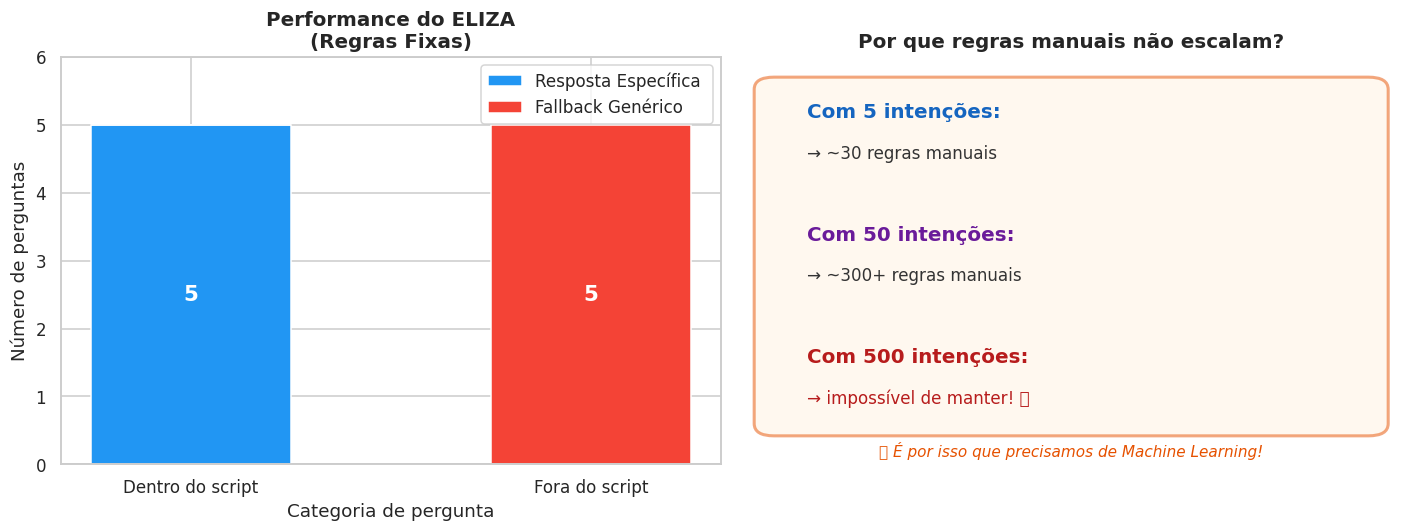


📌 Conclusão:
   • Chatbots por regras funcionam bem para domínios MUITO limitados
   • Qualquer variação de linguagem 'quebra' o chatbot
   • Para escalar, precisamos que o computador APRENDA os padrões sozinho


In [5]:
#  Visualizando as Limitações do Chatbot por Regras
# Vamos testar perguntas "fora do script" e mostrar com um
# gráfico quantas respostas são genéricas (fallback) vs. corretas

# Perguntas variadas — algumas dentro do script, outras fora
perguntas_variadas = {
    "Dentro do script": [
        "Eu me sinto cansado",
        "Não consigo dormir direito",
        "Eu preciso de ajuda",
        "Meu chefe é difícil",
        "Olá!",
    ],
    "Fora do script": [
        "Qual é a capital do Brasil?",
        "Quanto custa o produto X?",
        "Agende uma reunião amanhã",
        "Me manda o boleto",
        "Quero cancelar meu pedido",
    ],
}

# Contar respostas úteis vs. fallback
resultados = {}
for categoria, perguntas in perguntas_variadas.items():
    fallbacks = sum(1 for p in perguntas if eliza_responder(p) in FALLBACKS)
    especificas = len(perguntas) - fallbacks
    resultados[categoria] = {"Resposta Específica": especificas,
                              "Fallback Genérico": fallbacks}

#  Gráfico de barras empilhadas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: barras empilhadas por categoria
categorias = list(resultados.keys())
especificas = [resultados[c]["Resposta Específica"] for c in categorias]
fallback_count = [resultados[c]["Fallback Genérico"] for c in categorias]

bars1 = ax1.bar(categorias, especificas, color="#2196F3", label="Resposta Específica ", width=0.5)
bars2 = ax1.bar(categorias, fallback_count, bottom=especificas,
                color="#F44336", label="Fallback Genérico ", width=0.5)

ax1.set_title("Performance do ELIZA\n(Regras Fixas)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Número de perguntas")
ax1.set_ylim(0, 6)
ax1.legend()
ax1.set_xlabel("Categoria de pergunta")

# Adicionar rótulos nas barras
for bar, val in zip(bars1, especificas):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                 str(val), ha='center', va='center', color='white', fontweight='bold', fontsize=14)
for bar, val, base in zip(bars2, fallback_count, especificas):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, base + val/2,
                 str(val), ha='center', va='center', color='white', fontweight='bold', fontsize=14)

# Gráfico 2: Diagrama explicando o problema de escala
ax2.set_xlim(0, 10); ax2.set_ylim(0, 10); ax2.axis('off')
ax2.set_title("Por que regras manuais não escalam?", fontsize=13, fontweight="bold")

# Setas e texto explicativo
dados_problema = [
    (1, 8.5, "Com 5 intenções:", "#1565c0", 13),
    (1, 7.5, "→ ~30 regras manuais", "#333", 11),
    (1, 5.5, "Com 50 intenções:", "#6a1b9a", 13),
    (1, 4.5, "→ ~300+ regras manuais", "#333", 11),
    (1, 2.5, "Com 500 intenções:", "#b71c1c", 13),
    (1, 1.5, "→ impossível de manter! 💥", "#b71c1c", 11),
]
for x, y, txt, cor, sz in dados_problema:
    ax2.text(x, y, txt, fontsize=sz, color=cor,
             fontweight='bold' if sz == 13 else 'normal')

ax2.add_patch(mpatches.FancyBboxPatch((0.5, 1), 9, 8.2,
    boxstyle="round,pad=0.3", linewidth=2,
    edgecolor="#e65100", facecolor="#fff3e0", alpha=0.5))

ax2.text(5, 0.2, "👆 É por isso que precisamos de Machine Learning!",
         ha='center', fontsize=10, color="#e65100", style='italic')

plt.tight_layout()
plt.savefig("aula01_limitacoes_regras.png", dpi=110, bbox_inches="tight")
plt.show()

print("\n📌 Conclusão:")
print("   • Chatbots por regras funcionam bem para domínios MUITO limitados")
print("   • Qualquer variação de linguagem 'quebra' o chatbot")
print("   • Para escalar, precisamos que o computador APRENDA os padrões sozinho")

---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;">
        <div>
            <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 3</span>
            <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Arquitetura de um Chatbot Moderno</h2>
            <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"O caminho da mensagem até a resposta."</p>
        </div>
    </div>
</div>

### O caminho da mensagem até a resposta

Quando você digita algo para um chatbot profissional, sua mensagem passa por um **pipeline** (sequência) de processamentos. Veja o fluxo:

```
┌──────────────────────────────────────────────────────────────┐
│                                                              │
│  👤 "Quero cancelar meu pedido 12345"                        │
│                     │                                        │
│                     ▼                                        │
│         ┌───────────────────────┐                            │
│         │  PRÉ-PROCESSAMENTO    │  → limpar, tokenizar       │
│         │  (lowercase, tokens)  │    "quero cancelar meu     │
│         └──────────┬────────────┘     pedido 12345"          │
│                    ▼                                         │
│         ┌───────────────────────┐                            │
│         │  NLU — ENTENDIMENTO   │  → Intenção: #cancelar     │
│         │  Natural Language     │     Entidade: @pedido=12345│
│         │  Understanding        │                            │
│         └──────────┬────────────┘                            │
│                    ▼                                         │
│         ┌───────────────────────┐                            │
│         │  GERENCIADOR DE       │  → Verifica contexto       │
│         │  DIÁLOGO              │     Decide próximo passo   │
│         └──────────┬────────────┘                            │
│                    ▼                                         │
│         ┌───────────────────────┐                            │
│         │  NLG — GERAÇÃO        │  → "Pedido 12345 cancelado │
│         │  Natural Language     │     com sucesso!"          │
│         │  Generation           │                            │
│         └──────────┬────────────┘                            │
│                    ▼                                         │
│  🤖 "Seu pedido 12345 foi cancelado. Reembolso em 5 dias."   │
│                                                              │
└──────────────────────────────────────────────────────────────┘
```

### Os 3 conceitos mais importantes do NLU

| Conceito | O que é | Exemplo |
|----------|---------|---------|
| **Intenção (Intent)** | O **objetivo** do usuário — o que ele quer fazer | `"quero cancelar"` → `#cancelar_pedido` |
| **Entidade (Entity)** | Os **dados** mencionados na frase | `"pedido 12345"` → `@numero = 12345` |
| **Contexto** | A **memória** da conversa — o que já foi dito | `{"usuario": "Ana", "pedido": "12345"}` |

<div style="background:#e8d5f5; border-left:5px solid #5b2c8d; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#5b2c8d;">💡 </strong><span style="color:#5b2c8d;"><strong>Analogia com o dia a dia:</strong> Imagine que você liga para uma empresa e fala: <em>"Quero cancelar o pedido que fiz ontem"</em>. O atendente identifica a <strong>intenção</strong> (cancelar pedido), a <strong>entidade</strong> ("ontem" — dado temporal) e consulta o <strong>contexto</strong> (seu histórico). O NLU faz exatamente isso, só que automaticamente com ML!</span>
</div>

---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;">
        <div>
            <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 4</span>
            <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">NLU com Machine Learning</h2>
            <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Como o computador aprende a classificar intenções?"</p>
        </div>
    </div>
</div>

### Como o computador "aprende" a classificar intenções?

Aqui está o coração de um chatbot moderno. Em vez de escrever regras manualmente, vamos **mostrar exemplos** para o modelo e ele aprende a generalizar!

**O processo de treinamento:**
```
Dados de treino (exemplos rotulados)
        ↓
Vetorização (TF-IDF) — transforma texto em números
        ↓
Treinamento do classificador (Regressão Logística)
        ↓
Modelo capaz de classificar novas frases!
```

### O que é TF-IDF?

**TF-IDF** (Term Frequency — Inverse Document Frequency) transforma frases em vetores numéricos. A ideia: palavras que aparecem muito em um tipo de frase e pouco nas outras são mais **discriminativas**.

```
"quero cancelar meu pedido"
         ↓  TF-IDF
[0.0, 0.8, 0.0, 0.6, 0.0, 0.4, 0.0, ...]
  ↑             ↑             ↑
"cancelar"   "pedido"      "quero"
(peso alto)  (peso alto)  (peso médio — aparece em tudo)
```

In [6]:

# Dataset de Intenções e Treinamento do Classificador
# Aqui criamos os "dados de treino": exemplos de frases para
# cada intenção. Quanto mais variados, melhor o modelo aprende!

#  Dataset: {intenção: [exemplos de frases]}
DATASET_INTENCOES = {
    "rastrear_pedido": [
        "onde está meu pedido",
        "quero rastrear minha encomenda",
        "qual o status do meu pedido",
        "meu pedido chegou",
        "quando chega minha compra",
        "cadê meu produto",
        "me diz onde tá meu pedido",
        "quero saber onde está minha compra",
        "status da entrega",
        "meu pedido foi enviado",
    ],
    "cancelar_pedido": [
        "quero cancelar",
        "pode cancelar meu pedido",
        "desistir da compra",
        "cancelar minha compra",
        "não quero mais o produto",
        "cancela o pedido",
        "quero desistir da compra",
        "cancela tudo",
        "como faço para cancelar",
        "quero devolver e cancelar",
    ],
    "segunda_via_boleto": [
        "preciso do boleto",
        "segunda via do boleto",
        "reemitir boleto",
        "perdi o boleto",
        "não recebi o boleto",
        "gerar novo boleto",
        "me manda o boleto",
        "quero pagar mas perdi o boleto",
        "boleto vencido",
        "como pago o boleto",
    ],
    "falar_com_humano": [
        "falar com atendente",
        "quero um humano",
        "transferir para atendente",
        "atendimento humano",
        "preciso de um operador",
        "sair do bot",
        "não quero falar com robô",
        "coloca um humano aqui",
        "quero falar com uma pessoa",
        "atendente por favor",
    ],
    "saudacao": [
        "oi",
        "olá",
        "bom dia",
        "boa tarde",
        "boa noite",
        "oi tudo bem",
        "hey",
        "oi como vai",
        "bom dia, tudo bem",
        "olá pode me ajudar",
    ],
}

#  Transformar dicionário em listas X (frases) e y (labels)
X_treino = []
y_treino = []
for intencao, exemplos in DATASET_INTENCOES.items():
    for exemplo in exemplos:
        X_treino.append(exemplo)
        y_treino.append(intencao)

print(f"Dataset criado!")
print(f"   • Total de exemplos de treino: {len(X_treino)}")
print(f"   • Número de intenções: {len(DATASET_INTENCOES)}")
print(f"\n   Distribuição por intenção:")
from collections import Counter
contagem = Counter(y_treino)
for intencao, qtd in contagem.items():
    barra = "█" * qtd
    print(f"     {intencao:25s}: {barra} ({qtd})")

Dataset criado!
   • Total de exemplos de treino: 50
   • Número de intenções: 5

   Distribuição por intenção:
     rastrear_pedido          : ██████████ (10)
     cancelar_pedido          : ██████████ (10)
     segunda_via_boleto       : ██████████ (10)
     falar_com_humano         : ██████████ (10)
     saudacao                 : ██████████ (10)


In [7]:

# Treinando o Classificador de Intenções
# Usamos um PIPELINE do scikit-learn:
#   1. TfidfVectorizer → transforma texto em vetor numérico
#   2. LogisticRegression → classifica o vetor na intenção certa
#
# Pipeline encadeia os dois passos automaticamente!

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

#  Criando o Pipeline
# Pense como uma linha de montagem:
#   Texto bruto → TF-IDF (vetorização) → Classificador → Intenção

classificador_nlu = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",          # analisa por palavras
        ngram_range=(1, 2),       # considera palavras sozinhas E pares de palavras
        min_df=1,                 # palavra deve aparecer ao menos 1x
        strip_accents="unicode",  # trata acentos
        lowercase=True,           # normaliza para minúsculo
    )),
    ("clf", LogisticRegression(
        max_iter=1000,            # número máximo de iterações de treino
        C=5.0,                    # força da regularização (quanto maior, menos regularização)
        random_state=42,          # garante reprodutibilidade
    )),
])

#  Treinamento
# .fit(X, y) = "aprenda com estes exemplos e rótulos"
classificador_nlu.fit(X_treino, y_treino)
print("Modelo treinado com sucesso!")

#  Testando com novas frases
# Estas frases NÃO estavam no treino — o modelo deve generalizar!
frases_teste = [
    "cadê minha encomenda?",           # variação de rastrear
    "quero desistir",                  # variação de cancelar
    "me manda o boleto de novo",       # variação de boleto
    "preciso falar com alguém",        # variação de humano
    "boa tarde",                       # saudação
    "quando meu produto vai chegar?",  # rastrear com palavras diferentes
]

print(f"\n{'Frase':<45} {'Intenção Prevista':<25} {'Confiança':>10}")
print("" * 82)

probabilidades = classificador_nlu.predict_proba(frases_teste)
predicoes = classificador_nlu.predict(frases_teste)
classes = classificador_nlu.classes_

for frase, pred, probs in zip(frases_teste, predicoes, probabilidades):
    confianca = probs.max()
    emoji = "OK" if confianca > 0.7 else "Atenção"
    print(f"  {emoji} {frase:<43} {pred:<25} {confianca:>9.1%}")

Modelo treinado com sucesso!

Frase                                         Intenção Prevista          Confiança

  Atenção cadê minha encomenda?                       rastrear_pedido               62.2%
  Atenção quero desistir                              cancelar_pedido               53.6%
  Atenção me manda o boleto de novo                   segunda_via_boleto            69.5%
  OK preciso falar com alguém                    falar_com_humano              73.5%
  OK boa tarde                                   saudacao                      72.8%
  Atenção quando meu produto vai chegar?              rastrear_pedido               56.8%


/tmp/ipykernel_8901/3094448325.py:68: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3)
/tmp/ipykernel_8901/3094448325.py:69: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig("aula01_visualizacao_nlu.png", dpi=110, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


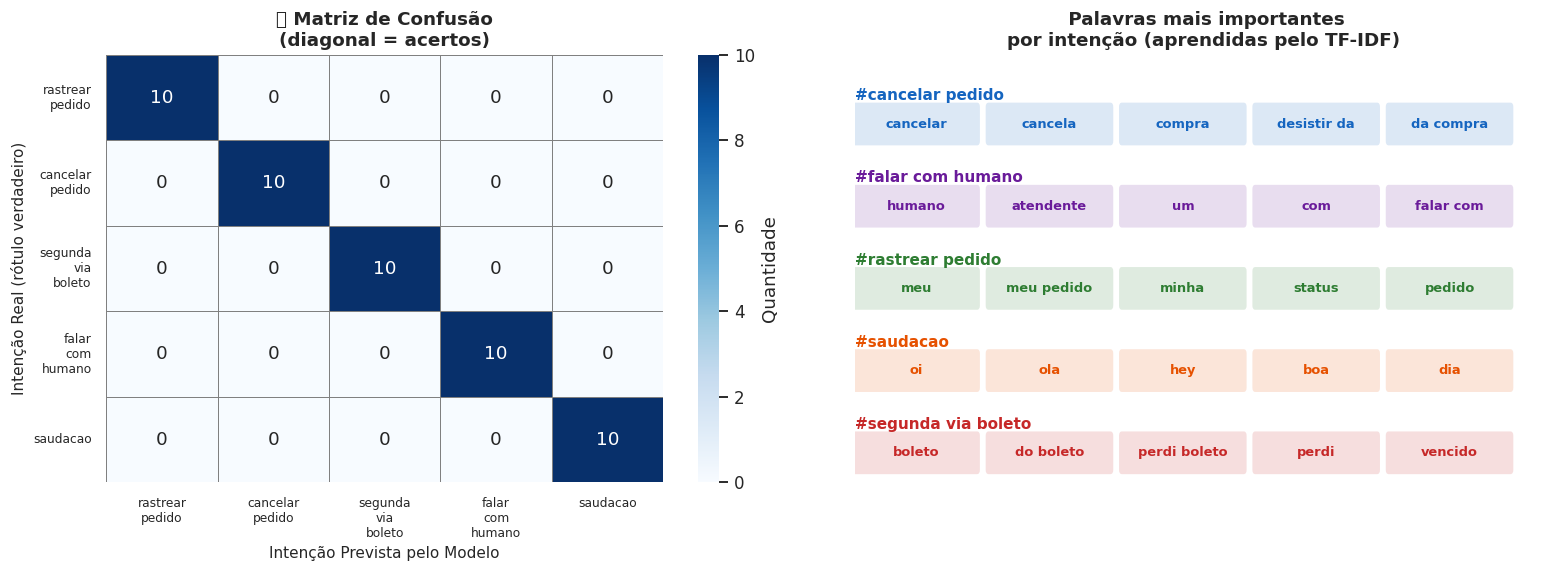

Como ler a Matriz de Confusão:
   • Cada LINHA = intenção real do usuário
   • Cada COLUNA = intenção que o modelo previu
   • Números na DIAGONAL (azul escuro) = acertos
   • Números FORA da diagonal = confusões entre intenções


In [8]:

# Visualizando o que o Modelo Aprendeu
# Dois gráficos didáticos:
# 1. Matriz de Confusão — onde o modelo acerta/erra
# 2. Palavras mais importantes por intenção (TF-IDF weights)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#  Gráfico 1: Matriz de Confusão
# A matriz mostra: para cada intenção real (linha),
# o que o modelo previu (coluna).
# Diagonal = acertos. Fora da diagonal = erros.
y_pred_treino = classificador_nlu.predict(X_treino)
cm = confusion_matrix(y_treino, y_pred_treino, labels=list(DATASET_INTENCOES.keys()))

sns.heatmap(
    cm, ax=ax1,
    annot=True, fmt="d",
    xticklabels=[i.replace("_", "\n") for i in DATASET_INTENCOES.keys()],
    yticklabels=[i.replace("_", "\n") for i in DATASET_INTENCOES.keys()],
    cmap="Blues", linewidths=0.5, linecolor="gray",
    cbar_kws={"label": "Quantidade"},
)
ax1.set_title("🎯 Matriz de Confusão\n(diagonal = acertos)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Intenção Prevista pelo Modelo", fontsize=10)
ax1.set_ylabel("Intenção Real (rótulo verdadeiro)", fontsize=10)
ax1.tick_params(axis='x', labelsize=8)
ax1.tick_params(axis='y', labelsize=8, rotation=0)

#  Gráfico 2: Top palavras por intenção
# O TF-IDF aprendeu quais palavras são mais "características"
# de cada intenção. Vamos visualizar as top 4.

tfidf = classificador_nlu.named_steps["tfidf"]
clf   = classificador_nlu.named_steps["clf"]
vocab = np.array(tfidf.get_feature_names_out())
classes_ord = clf.classes_

# Para cada classe, pegar os coeficientes mais altos
top_n = 5
cores_intencao = ["#1565c0", "#6a1b9a", "#2e7d32", "#e65100", "#c62828"]

ax2.set_xlim(0, 12); ax2.set_ylim(-0.5, len(classes_ord) - 0.3); ax2.axis("off")
ax2.set_title(" Palavras mais importantes\npor intenção (aprendidas pelo TF-IDF)",
              fontsize=12, fontweight="bold")

for i, (classe, cor) in enumerate(zip(classes_ord, cores_intencao)):
    coef_idx = list(clf.classes_).index(classe)
    top_idx  = np.argsort(clf.coef_[coef_idx])[-top_n:][::-1]
    top_palavras = vocab[top_idx]

    y_pos = len(classes_ord) - 1 - i
    ax2.text(0, y_pos + 0.15, f"#{classe.replace('_', ' ')}",
             fontsize=10, fontweight="bold", color=cor)

    for j, palavra in enumerate(top_palavras):
        ax2.add_patch(mpatches.FancyBboxPatch(
            (j * 2.3, y_pos - 0.35), 2.1, 0.42,
            boxstyle="round,pad=0.05", facecolor=cor, alpha=0.15, linewidth=0
        ))
        ax2.text(j * 2.3 + 1.05, y_pos - 0.14, palavra,
                 ha="center", va="center", fontsize=8.5, color=cor, fontweight="bold")

plt.tight_layout(pad=3)
plt.savefig("aula01_visualizacao_nlu.png", dpi=110, bbox_inches="tight")
plt.show()

print("Como ler a Matriz de Confusão:")
print("   • Cada LINHA = intenção real do usuário")
print("   • Cada COLUNA = intenção que o modelo previu")
print("   • Números na DIAGONAL (azul escuro) = acertos")
print("   • Números FORA da diagonal = confusões entre intenções")

---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;">
        <div>
            <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 5</span>
            <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Chatbot Completo com NLU + Gerenciamento de Diálogo</h2>
            <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Juntando tudo: do texto à resposta."</p>
        </div>
    </div>
</div>

### Juntando tudo: do texto à resposta

Agora vamos construir um **chatbot completo** que usa o classificador de ML que treinamos. Ele vai:

1. **Receber** a mensagem do usuário
2. **Classificar** a intenção com nosso Pipeline TF-IDF + Regressão Logística
3. **Extrair entidades** com regex (número de pedido, CPF)
4. **Gerenciar o contexto** — lembrar informações entre turnos
5. **Gerar** a resposta correta

### O que é "Gerenciamento de Contexto"?

Imagine a conversa:
```
Turno 1:  Usuário: "Quero cancelar meu pedido"
          Bot: "Qual é o número do pedido?"   ← ainda não sabe o número

Turno 2:  Usuário: "É o 12345"
          Bot: "Pedido 12345 cancelado!"       ← usou o número do turno anterior!
```

O bot precisa **lembrar** o que foi dito. Isso é o **contexto** — uma variável que guarda informações entre as mensagens.

In [9]:

# Chatbot Completo: NLU + Extrator de Entidades
#             + Gerenciador de Diálogo

import re

#  Extrator de Entidades com Regex
# Entidades são os "dados" que o usuário menciona na frase.
# Usamos regex para extrair padrões específicos.

def extrair_entidades(texto: str) -> dict:
    """
    Extrai entidades de interesse do texto usando expressões regulares.
    Retorna um dicionário com as entidades encontradas.
    """
    entidades = {}
    texto_lower = texto.lower()

    # Número de pedido: sequência de letras/números após "pedido", "número" etc.
    match_pedido = re.search(
        r'(?:pedido|número|encomenda|compra)[\s:#-]*([A-Z0-9]{4,10})',
        texto, re.IGNORECASE
    )
    # Também tenta pegar só números se o bot já sabe que está esperando um pedido
    match_numero = re.search(r'\b(\d{4,6})\b', texto)

    if match_pedido:
        entidades["numero_pedido"] = match_pedido.group(1).upper()
    elif match_numero:
        entidades["numero_pedido"] = match_numero.group(1)

    # CPF: formato 000.000.000-00 ou 00000000000
    match_cpf = re.search(
        r'\b(\d{3}\.?\d{3}\.?\d{3}-?\d{2})\b', texto
    )
    if match_cpf:
        entidades["cpf"] = match_cpf.group(1)

    return entidades


#  Respostas por intenção (templates)
# Em um chatbot real, essas respostas viriam de um banco de dados
# ou seriam geradas por um modelo de linguagem.

RESPOSTAS = {
    "saudacao": [
        "Olá! 👋 Sou o assistente virtual. Como posso te ajudar hoje?",
        "Oi, tudo bem? Em que posso ajudar?",
        "Boas-vindas! Posso te ajudar com pedidos, boletos e muito mais.",
    ],
    "rastrear_pedido": {
        "sem_numero": "Claro! Para rastrear, preciso do número do seu pedido. Pode informar?",
        "com_numero": lambda n: f"📦 Seu pedido {n} está a caminho! Previsão de entrega: amanhã entre 14h–18h.",
    },
    "cancelar_pedido": {
        "sem_numero": "Entendido. Para cancelar, qual é o número do pedido?",
        "confirmar":  lambda n: f"Você quer cancelar o pedido {n}? Responda SIM para confirmar.",
        "confirmado": lambda n: f"✅ Pedido {n} cancelado! Reembolso em até 5 dias úteis.",
        "negado":     "Certo! Seu pedido foi mantido. Posso ajudar com mais alguma coisa?",
    },
    "segunda_via_boleto": {
        "sem_cpf":    "Para gerar a 2ª via, preciso do seu CPF. Pode informar?",
        "com_cpf":    lambda cpf: f"🧾 Boleto gerado para o CPF {cpf}. Link: https://banco.exemplo.com/boleto/{cpf[-4:]}",
    },
    "falar_com_humano": "Transferindo você para um atendente humano... ⏳ Aguarde um momento.",
}


#  Gerenciador de Diálogo
class ChatbotNLU:
    """
    Chatbot que usa ML para classificar intenções e mantém
    variáveis de contexto entre turnos da conversa.
    """

    CONFIANCA_MINIMA = 0.35   # abaixo disso, considera "não entendeu"

    def __init__(self, classificador):
        self.clf = classificador
        self.contexto = {}      # memória da conversa
        self.turno = 0

    def responder(self, mensagem: str) -> str:
        self.turno += 1
        texto = mensagem.strip()

        # 1. Extrair entidades e atualizar contexto
        entidades = extrair_entidades(texto)
        self.contexto.update(entidades)

        # 2. Classificar intenção com ML
        probs   = self.clf.predict_proba([texto])[0]
        intencao = self.clf.predict([texto])[0]
        confianca = probs.max()

        # 3. Verificar se há confirmação pendente
        if self.contexto.get("aguardando_confirmacao"):
            return self._processar_confirmacao(texto)

        # 4. Confiança baixa → pedir reformulação
        if confianca < self.CONFIANCA_MINIMA:
            return ("Hmm, não entendi bem. Pode reformular? "
                    "Posso ajudar com: rastreio de pedido, cancelamento, "
                    "2ª via de boleto ou transferir para atendente.")

        # 5. Rotear para o fluxo correto
        return self._rotear(intencao)

    def _rotear(self, intencao: str) -> str:
        """Direciona para o fluxo de resposta correto."""

        if intencao == "saudacao":
            return random.choice(RESPOSTAS["saudacao"])

        elif intencao == "rastrear_pedido":
            numero = self.contexto.get("numero_pedido")
            if not numero:
                self.contexto["ultimo_fluxo"] = "rastrear_pedido"
                return RESPOSTAS["rastrear_pedido"]["sem_numero"]
            return RESPOSTAS["rastrear_pedido"]["com_numero"](numero)

        elif intencao == "cancelar_pedido":
            numero = self.contexto.get("numero_pedido")
            if not numero:
                self.contexto["ultimo_fluxo"] = "cancelar_pedido"
                return RESPOSTAS["cancelar_pedido"]["sem_numero"]
            # Pedir confirmação antes de cancelar
            self.contexto["aguardando_confirmacao"] = "cancelar_pedido"
            return RESPOSTAS["cancelar_pedido"]["confirmar"](numero)

        elif intencao == "segunda_via_boleto":
            cpf = self.contexto.get("cpf")
            if not cpf:
                self.contexto["ultimo_fluxo"] = "segunda_via_boleto"
                return RESPOSTAS["segunda_via_boleto"]["sem_cpf"]
            return RESPOSTAS["segunda_via_boleto"]["com_cpf"](cpf)

        elif intencao == "falar_com_humano":
            return RESPOSTAS["falar_com_humano"]

        return "Desculpe, não consegui entender. Pode tentar de outra forma?"

    def _processar_confirmacao(self, texto: str) -> str:
        """Processa respostas SIM/NÃO quando há uma confirmação pendente."""
        fluxo = self.contexto.pop("aguardando_confirmacao")
        texto_lower = texto.lower()
        confirmou = any(p in texto_lower for p in ["sim", "s", "yes", "confirmar", "pode", "ok"])

        if fluxo == "cancelar_pedido":
            numero = self.contexto.get("numero_pedido", "???")
            if confirmou:
                return RESPOSTAS["cancelar_pedido"]["confirmado"](numero)
            return RESPOSTAS["cancelar_pedido"]["negado"]

        return "Entendido."


print("Classe ChatbotNLU definida!")
print("\n   O chatbot vai:")
print("   1. Classificar a intenção com ML (TF-IDF + Regressão Logística)")
print("   2. Extrair entidades com regex (número de pedido, CPF)")
print("   3. Manter contexto entre turnos (memória da conversa)")
print("   4. Perguntar informações que faltam (slot-filling)")

Classe ChatbotNLU definida!

   O chatbot vai:
   1. Classificar a intenção com ML (TF-IDF + Regressão Logística)
   2. Extrair entidades com regex (número de pedido, CPF)
   3. Manter contexto entre turnos (memória da conversa)
   4. Perguntar informações que faltam (slot-filling)


In [10]:

# Simulando uma Conversa Realista com o ChatbotNLU
# Observe como o bot:
# - Usa ML para identificar as intenções
# - Pede informações faltantes (slot-filling)
# - Lembra do número do pedido entre turnos
# - Pede confirmação antes de ações irreversíveis

bot = ChatbotNLU(classificador_nlu)

# Conversa simulando um atendimento real
conversa = [
    ("Oi, tudo bem?",                    "saudacao"),
    ("Quero cancelar meu pedido",         "sem número → pede"),
    ("É o pedido 87432",                  "fornece número"),
    ("Sim, pode cancelar",               "confirma cancelamento"),
    ("Me manda o boleto também",         "segunda via"),
    ("Meu CPF é 123.456.789-00",         "fornece CPF"),
    ("Obrigado, pode transferir humano", "escala para humano"),
]

print("=" * 70)
print("  CONVERSA REALISTA — ChatbotNLU (ML + Contexto)")
print("=" * 70)

for fala, descricao in conversa:
    # Mostra a intenção classificada pelo ML para fins didáticos
    intencao_ml = bot.clf.predict([fala])[0]
    prob_ml     = bot.clf.predict_proba([fala])[0].max()
    entidades   = extrair_entidades(fala)

    resposta = bot.responder(fala)

    print(f"\n  ┌── Turno {bot.turno} ─────────────────────────────────────────")
    print(f"  │   Usuário:  \"{fala}\"")
    print(f"  │   ML detectou: intenção='{intencao_ml}' ({prob_ml:.0%} conf.)", end="")
    if entidades:
        print(f"  |  entidades={entidades}", end="")
    print()
    print(f"  │   Contexto: {bot.contexto}")
    print(f"  │")
    print(f"  │   Bot: \"{resposta}\"")
    print(f"  └────────────────────────────────────────────────────────")

  CONVERSA REALISTA — ChatbotNLU (ML + Contexto)

  ┌── Turno 1 ─────────────────────────────────────────
  │   Usuário:  "Oi, tudo bem?"
  │   ML detectou: intenção='saudacao' (79% conf.)
  │   Contexto: {}
  │
  │   Bot: "Olá! 👋 Sou o assistente virtual. Como posso te ajudar hoje?"
  └────────────────────────────────────────────────────────

  ┌── Turno 2 ─────────────────────────────────────────
  │   Usuário:  "Quero cancelar meu pedido"
  │   ML detectou: intenção='cancelar_pedido' (68% conf.)
  │   Contexto: {'ultimo_fluxo': 'cancelar_pedido'}
  │
  │   Bot: "Entendido. Para cancelar, qual é o número do pedido?"
  └────────────────────────────────────────────────────────

  ┌── Turno 3 ─────────────────────────────────────────
  │   Usuário:  "É o pedido 87432"
  │   ML detectou: intenção='rastrear_pedido' (44% conf.)  |  entidades={'numero_pedido': '87432'}
  │   Contexto: {'ultimo_fluxo': 'cancelar_pedido', 'numero_pedido': '87432'}
  │
  │   Bot: "📦 Seu pedido 87432 está a cam

---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;">
        <div>
            <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 6</span>
            <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">NLP com NLTK</h2>
            <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Processando texto como os profissionais."</p>
        </div>
    </div>
</div>

### Por que precisamos processar o texto antes de classificar?

Textos "crus" têm muito ruído. Antes de treinar um modelo de ML, profissionais aplicam um **pré-processamento** para normalizar o texto:

```
Texto original:    "Quero CANCELAR meu pedido!!!  Já perdi a paciência..."
        ↓  Tokenização
Tokens:            ["Quero", "CANCELAR", "meu", "pedido", "Já", "perdi", "paciência"]
        ↓  Lowercase + Remove stopwords
Filtrado:          ["cancelar", "pedido", "perdi", "paciência"]
        ↓  Stemming (reduz à raiz)
Stemmed:           ["cancel", "pedid", "perd", "paciênc"]
```

**Por que isso ajuda?**
- "Cancelar", "cancelamento", "cancela" → todos viram "cancel" → o modelo aprende uma vez
- Stopwords ("meu", "já", "a") são palavras sem significado → remover não perde informação
- Menos variação → modelo mais robusto com menos dados de treino

In [11]:

#  Pré-processamento de Texto com NLTK
# O NLTK (Natural Language Toolkit) é a biblioteca clássica
# de processamento de linguagem natural em Python.
# Vamos usar 3 técnicas fundamentais:
#   1. Tokenização — dividir em palavras/tokens
#   2. Remoção de stopwords — tirar palavras sem significado
#   3. Stemming — reduzir palavras à sua raiz

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer   # stemmer específico para português!

# Inicializar o stemmer para português
stemmer = RSLPStemmer()
stopwords_pt = set(stopwords.words("portuguese"))

def preprocessar_texto(texto: str, verbose: bool = False) -> list:
    """
    Aplica o pipeline completo de pré-processamento:
    1. Lowercase
    2. Tokenização
    3. Remove pontuação e caracteres especiais
    4. Remove stopwords
    5. Aplica stemming
    """
    # Passo 1: Lowercase
    texto_lower = texto.lower()

    # Passo 2: Tokenização (divide em lista de palavras)
    tokens = word_tokenize(texto_lower, language="portuguese")

    # Passo 3: Remove pontuação (mantém só palavras com letras/números)
    tokens_limpos = [t for t in tokens if t.isalpha()]

    # Passo 4: Remove stopwords
    tokens_sem_stop = [t for t in tokens_limpos if t not in stopwords_pt]

    # Passo 5: Stemming (reduz à raiz morfológica)
    tokens_stemmed = [stemmer.stem(t) for t in tokens_sem_stop]

    if verbose:
        print(f"  Original:         '{texto}'")
        print(f"  Lowercase:        '{texto_lower}'")
        print(f"  Tokens:            {tokens}")
        print(f"  Sem pontuação:     {tokens_limpos}")
        print(f"  Sem stopwords:     {tokens_sem_stop}")
        print(f"  Com stemming:      {tokens_stemmed}")

    return tokens_stemmed


#  Demonstração passo a passo
frases_demo = [
    "Quero CANCELAR meu pedido agora mesmo!",
    "Eu gostaria de rastrear a minha encomenda",
    "Não recebi o boleto, preciso de uma segunda via urgente",
]

print("=" * 65)
print("   PIPELINE DE PRÉ-PROCESSAMENTO (NLTK)")
print("=" * 65)

for frase in frases_demo:
    print(f"\n{''*62}")
    preprocessar_texto(frase, verbose=True)

#  Visualizando: com vs. sem pré-processamento
print(f"\n\n{''*62}")
print(" Comparando: com vs. sem pré-processamento\n")

pares = [
    ("cancelar", "cancelamento"),
    ("rastrear", "rastreamento"),
    ("cancelar", "cancela"),
    ("pedido", "pedidos"),
]

print(f"  {'Palavra 1':<20} {'Palavra 2':<20} {'Mesma raiz?':>12}")
print("  " + "" * 52)
for p1, p2 in pares:
    s1 = stemmer.stem(p1)
    s2 = stemmer.stem(p2)
    igual = "✅ Sim!" if s1 == s2 else "❌ Não"
    print(f"  {p1:<20} {p2:<20} {igual:>12}   (stems: '{s1}' / '{s2}')")

   PIPELINE DE PRÉ-PROCESSAMENTO (NLTK)


  Original:         'Quero CANCELAR meu pedido agora mesmo!'
  Lowercase:        'quero cancelar meu pedido agora mesmo!'
  Tokens:            ['quero', 'cancelar', 'meu', 'pedido', 'agora', 'mesmo', '!']
  Sem pontuação:     ['quero', 'cancelar', 'meu', 'pedido', 'agora', 'mesmo']
  Sem stopwords:     ['quero', 'cancelar', 'pedido', 'agora']
  Com stemming:      ['quer', 'cancel', 'ped', 'agor']


  Original:         'Eu gostaria de rastrear a minha encomenda'
  Lowercase:        'eu gostaria de rastrear a minha encomenda'
  Tokens:            ['eu', 'gostaria', 'de', 'rastrear', 'a', 'minha', 'encomenda']
  Sem pontuação:     ['eu', 'gostaria', 'de', 'rastrear', 'a', 'minha', 'encomenda']
  Sem stopwords:     ['gostaria', 'rastrear', 'encomenda']
  Com stemming:      ['gost', 'rastr', 'encomend']


  Original:         'Não recebi o boleto, preciso de uma segunda via urgente'
  Lowercase:        'não recebi o boleto, preciso de uma segunda via

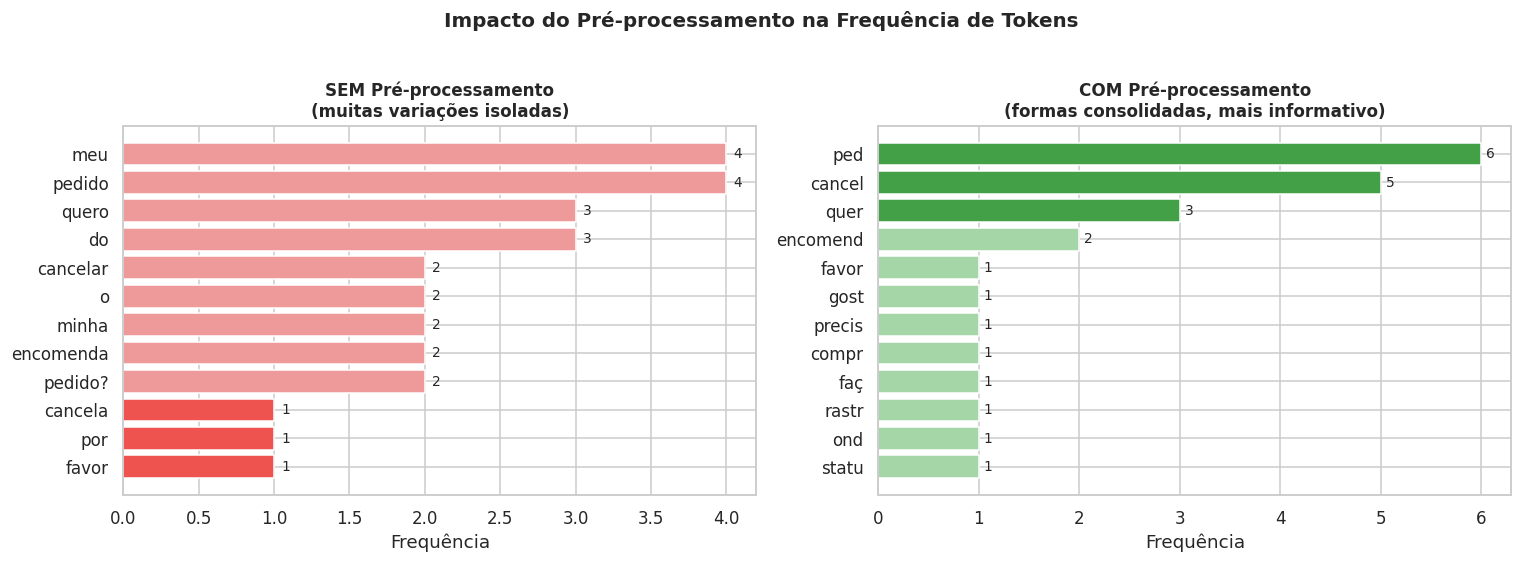

Observe:
   • SEM processamento: 'cancelar', 'cancela', 'cancelamento' são palavras DIFERENTES
   • COM processamento: todas viram o mesmo stem → o modelo aprende com menos dados!

   Vocabulário sem pré-proc: 28 palavras únicas
   Vocabulário com pré-proc: 14 palavras únicas  ← 50% menor!


In [12]:

# Visualizando o Impacto do Pré-processamento
# Gráfico comparando a frequência de palavras:
#   - Sem pré-processamento: muitas formas diferentes
#   - Com pré-processamento: formas consolidadas

from collections import Counter

# Corpus de exemplo com variações de frases
corpus_exemplo = [
    "Quero cancelar meu pedido",
    "Cancela o meu pedido por favor",
    "Gostaria de cancelamento do pedido",
    "Preciso cancelar essa compra",
    "Como faço para cancelar?",
    "Quero rastrear minha encomenda",
    "Onde está o meu pedido?",
    "Status do pedido?",
    "Quero saber do meu pedido",
    "Cadê minha encomenda",
]

# Frequência SEM pré-processamento
tokens_sem_proc = []
for frase in corpus_exemplo:
    tokens_sem_proc.extend(frase.lower().split())

# Frequência COM pré-processamento
tokens_com_proc = []
for frase in corpus_exemplo:
    tokens_com_proc.extend(preprocessar_texto(frase))

# Top 12 palavras em cada caso
top_sem = Counter(tokens_sem_proc).most_common(12)
top_com = Counter(tokens_com_proc).most_common(12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico 1: Sem pré-processamento ──────────────────────────
palavras_sem, freqs_sem = zip(*top_sem)
cores_sem = ["#ef5350" if f == 1 else "#ef9a9a" for f in freqs_sem]
bars = ax1.barh(palavras_sem[::-1], freqs_sem[::-1], color=cores_sem[::-1])
ax1.set_title("SEM Pré-processamento\n(muitas variações isoladas)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Frequência")
for bar, freq in zip(bars, freqs_sem[::-1]):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(freq), va='center', fontsize=9)

# ── Gráfico 2: Com pré-processamento ──────────────────────────
palavras_com, freqs_com = zip(*top_com)
cores_com = ["#43a047" if f >= 3 else "#a5d6a7" for f in freqs_com]
bars2 = ax2.barh(palavras_com[::-1], freqs_com[::-1], color=cores_com[::-1])
ax2.set_title("COM Pré-processamento\n(formas consolidadas, mais informativo)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Frequência")
for bar, freq in zip(bars2, freqs_com[::-1]):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(freq), va='center', fontsize=9)

plt.suptitle("Impacto do Pré-processamento na Frequência de Tokens",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("aula01_preprocessing.png", dpi=110, bbox_inches="tight")
plt.show()

print("Observe:")
print("   • SEM processamento: 'cancelar', 'cancela', 'cancelamento' são palavras DIFERENTES")
print("   • COM processamento: todas viram o mesmo stem → o modelo aprende com menos dados!")
print(f"\n   Vocabulário sem pré-proc: {len(set(tokens_sem_proc))} palavras únicas")
print(f"   Vocabulário com pré-proc: {len(set(tokens_com_proc))} palavras únicas  ← {round((1 - len(set(tokens_com_proc))/len(set(tokens_sem_proc)))*100)}% menor!")

---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;">
        <div>
            <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 7</span>
            <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">KPIs: Como Medir se o seu Chatbot está indo Bem?</h2>
            <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Sem métricas, você não sabe se está melhorando ou piorando."</p>
        </div>
    </div>
</div>

### Métricas que todo desenvolvedor de chatbot precisa acompanhar

Um chatbot em produção precisa ser **monitorado continuamente**. Sem métricas, você não sabe se está melhorando ou piorando!

| Métrica | O que mede | Meta típica |
|---------|-----------|------------|
| **Taxa de Resolução** | % de conversas resolvidas sem humano | > 70% |
| **Taxa de Fallback** | % de mensagens que o bot "não entendeu" | < 15% |
| **Confiança Média do NLU** | Certeza média do classificador | > 75% |
| **NPS do Chatbot** | Satisfação do usuário (0–10) | > 7.0 |

<div style="background:#e8d5f5; border-left:5px solid #5b2c8d; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#5b2c8d;">💡 </strong><span style="color:#5b2c8d;"><strong>Ciclo de melhoria contínua:</strong> Deploy do chatbot → Monitorar métricas → Analisar conversas com fallback → Adicionar novos exemplos de treino → Retreinar → voltar ao início.</span>
</div>

/tmp/ipykernel_8901/3546870026.py:66: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8901/3546870026.py:67: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.savefig("aula01_kpis_chatbot.png", dpi=110, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


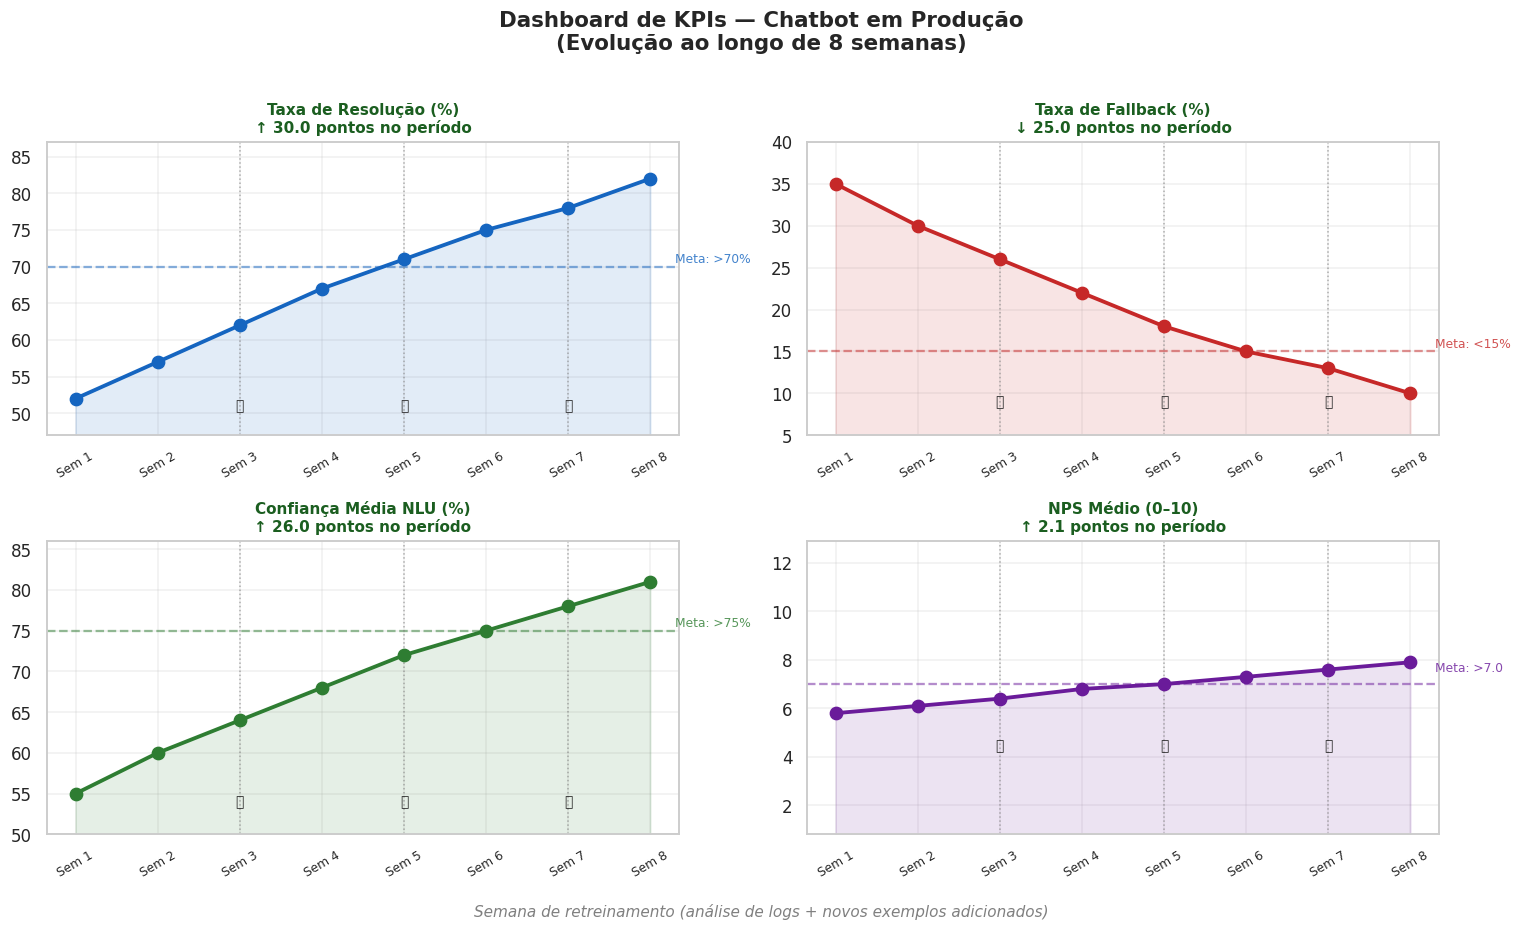

Leitura do Dashboard:
   • A taxa de RESOLUÇÃO deve SUBIR → sinal de melhoria
   • A taxa de FALLBACK deve CAIR → menos 'não entendi'
   • Cada loop representa um ciclo de melhoria com novos dados de treino
   • O NPS reflete a SATISFAÇÃO do usuário — sobe junto com as outras métricas


In [13]:

# CÉLULA 10 — Dashboard de KPIs do Chatbot
# Simulamos métricas de evolução ao longo de 8 semanas —
# representando um ciclo real de melhoria contínua.

import pandas as pd
import seaborn as sns

# Dados simulando evolução após ciclos de melhoria
semanas = [f"Sem {i}" for i in range(1, 9)]
df_kpi = pd.DataFrame({
    "semana": semanas,
    "taxa_resolucao":       [52, 57, 62, 67, 71, 75, 78, 82],
    "taxa_fallback":        [35, 30, 26, 22, 18, 15, 13, 10],
    "confianca_nlu":        [55, 60, 64, 68, 72, 75, 78, 81],
    "nps":                  [5.8, 6.1, 6.4, 6.8, 7.0, 7.3, 7.6, 7.9],
})

# Marcadores dos ciclos de retreinamento
ciclos_retreino = [2, 4, 6]  # semanas onde houve retreinamento

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Dashboard de KPIs — Chatbot em Produção\n(Evolução ao longo de 8 semanas)",
             fontsize=14, fontweight="bold", y=1.01)

metricas = [
    ("taxa_resolucao", "Taxa de Resolução (%)", "#1565c0", True,  70, "Meta: >70%"),
    ("taxa_fallback",  "Taxa de Fallback (%)",  "#c62828", False, 15, "Meta: <15%"),
    ("confianca_nlu",  "Confiança Média NLU (%)", "#2e7d32", True, 75, "Meta: >75%"),
    ("nps",            "NPS Médio (0–10)",       "#6a1b9a", True,  7, "Meta: >7.0"),
]

for ax, (col, titulo, cor, positivo, meta, meta_label) in zip(axes.flat, metricas):
    x = range(len(semanas))

    # Linha principal
    ax.plot(x, df_kpi[col], "o-", color=cor, linewidth=2.5, markersize=8, zorder=3)
    ax.fill_between(x, df_kpi[col], alpha=0.12, color=cor)

    # Linha de meta
    ax.axhline(meta, color=cor, linestyle="--", alpha=0.5, linewidth=1.5)
    ax.text(len(semanas) - 0.7, meta + 0.5, meta_label,
            fontsize=8, color=cor, alpha=0.8)

    # Marcar ciclos de retreinamento
    for ciclo in ciclos_retreino:
        ax.axvline(ciclo, color="gray", linestyle=":", alpha=0.6, linewidth=1)
        ax.text(ciclo, df_kpi[col].min() - 1.5, "🔄", ha="center", fontsize=9)

    # Seta de evolução no título
    delta = df_kpi[col].iloc[-1] - df_kpi[col].iloc[0]
    seta = "↑" if delta > 0 else "↓"
    cor_delta = "#1b5e20" if (delta > 0) == positivo else "#b71c1c"
    ax.set_title(f"{titulo}\n{seta} {abs(delta):.1f} pontos no período",
                 fontsize=10, fontweight="bold", color=cor_delta)

    ax.set_xticks(x)
    ax.set_xticklabels(semanas, rotation=30, fontsize=8)
    ax.set_ylim(df_kpi[col].min() - 5, df_kpi[col].max() + 5)
    ax.grid(True, alpha=0.3)

# Legenda dos ciclos
fig.text(0.5, -0.02,
         "Semana de retreinamento (análise de logs + novos exemplos adicionados)",
         ha="center", fontsize=10, color="gray", style="italic")

plt.tight_layout()
plt.savefig("aula01_kpis_chatbot.png", dpi=110, bbox_inches="tight")
plt.show()

print("Leitura do Dashboard:")
print("   • A taxa de RESOLUÇÃO deve SUBIR → sinal de melhoria")
print("   • A taxa de FALLBACK deve CAIR → menos 'não entendi'")
print("   • Cada loop representa um ciclo de melhoria com novos dados de treino")
print("   • O NPS reflete a SATISFAÇÃO do usuário — sobe junto com as outras métricas")

---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;">
        <div>
            <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 8</span>
            <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Exercícios Práticos</h2>
            <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Agora é com você — sem código pronto."</p>
        </div>
    </div>
</div>

### As regras dos exercícios

- Cada exercício tem uma **pergunta analítica** ou tarefa de implementação
- O código deve incluir comentários explicando o raciocínio
- Gabaritos comentados ao final de cada bloco — só olhe depois de tentar!
---

### Exercício 1 — Adicionando uma Nova Intenção ao Dataset 🟢 Fácil

> **Objetivo:** Entender como dados de treino impactam o modelo.

Adicione a intenção `"trocar_produto"` ao `DATASET_INTENCOES` com pelo menos **8 exemplos variados** de frases, depois retreine o classificador e teste com frases novas.

```python
# Dica de estrutura:
DATASET_INTENCOES["trocar_produto"] = [
    "quero trocar meu produto",
    # ... adicione mais 7 exemplos aqui
]
```

**Perguntas para reflexão:**
1. Com apenas 3 exemplos o modelo acerta? E com 8? E com 15?
2. Que tipo de variação de frase ajuda mais o modelo?

In [14]:
# EXERCÍCIO 1 — Implemente aqui
# PASSO 1: Adicione exemplos para a nova intenção
DATASET_INTENCOES["trocar_produto"] = [
    "quero trocar meu produto",
    # TODO: adicione pelo menos 7 exemplos variados abaixo
    # Dica: varie o vocabulário! "trocar", "substituir", "devolver para troca", etc.
]

# PASSO 2: Reconstrua X e y
X_ex1, y_ex1 = [], []
for intencao, exemplos in DATASET_INTENCOES.items():
    for exemplo in exemplos:
        X_ex1.append(exemplo)
        y_ex1.append(intencao)

# PASSO 3: Retreine o pipeline (mesmo código de antes!)
clf_ex1 = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), strip_accents="unicode", lowercase=True)),
    ("clf",   LogisticRegression(max_iter=1000, C=5.0, random_state=42)),
])
clf_ex1.fit(X_ex1, y_ex1)

# PASSO 4: Teste com frases novas
frases_teste_ex1 = [
    "quero substituir o produto com defeito",
    "como faço a troca?",
    "o item veio errado, quero trocar",
]

print("Resultados do Exercício 1:")
for frase in frases_teste_ex1:
    pred = clf_ex1.predict([frase])[0]
    conf = clf_ex1.predict_proba([frase])[0].max()
    print(f"  '{frase}' → {pred} ({conf:.0%})")

Resultados do Exercício 1:
  'quero substituir o produto com defeito' → falar_com_humano (34%)
  'como faço a troca?' → cancelar_pedido (38%)
  'o item veio errado, quero trocar' → cancelar_pedido (20%)


---

### Exercício 2 — Expandindo o Chatbot com Slot-Filling Intermediário

> **Objetivo:** Implementar o fluxo completo de uma nova intenção no `ChatbotNLU`.

Implemente o fluxo de **troca de produto** na classe `ChatbotNLU`:

- Se o usuário pedir troca sem informar o número do pedido → pedir o número
- Se já tiver o número no contexto → perguntar o **motivo** da troca (produto com defeito / produto errado / arrependimento)
- Com pedido + motivo → confirmar e "registrar" a troca

**Dicas:**
- Adicione um novo `elif intencao == "trocar_produto":` no método `_rotear`
- Use `self.contexto.get("numero_pedido")` para verificar se o número já foi fornecido
- Crie uma variável `self.contexto["motivo_troca"]` para guardar o motivo

<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">Critério de sucesso: a conversa abaixo deve funcionar corretamente:<br><br>
👤 "Quero trocar meu produto" → 🤖 "Qual é o número do pedido?"<br>
👤 "Pedido 99876" → 🤖 "Qual o motivo? (defeito/errado/arrependimento)"<br>
👤 "Veio com defeito" → 🤖 "Troca do pedido 99876 registrada!"</span>
</div>

In [15]:
# EXERCÍCIO 2 — Implemente aqui

class ChatbotNLUExpandido(ChatbotNLU):
    """
    Herda tudo do ChatbotNLU e adiciona o fluxo de troca de produto.
    Em Python, herança permite reutilizar código e apenas SOBRESCREVER
    o que precisamos mudar — neste caso, o método _rotear.
    """

    def _rotear(self, intencao: str) -> str:
        # Novo fluxo: troca de produto
        if intencao == "trocar_produto":
            # TODO: implementar o fluxo com slot-filling de 3 etapas
            # ETAPA 1: sem número de pedido → pedir
            # ETAPA 2: com número, sem motivo → pedir motivo
            # ETAPA 3: com número e motivo → confirmar troca
            return "Fluxo de troca em construção — implemente aqui! 🔨"

        # Para todas as outras intenções, usa o comportamento original
        return super()._rotear(intencao)


#  Teste do fluxo
bot_ex2 = ChatbotNLUExpandido(clf_ex1)  # usa o classificador do exercício 1

conversa_troca = [
    "Quero trocar meu produto",
    "Pedido 99876",
    "Veio com defeito",
]

print("Teste do Exercício 2 — Fluxo de Troca:")
print("=" * 50)
for msg in conversa_troca:
    resp = bot_ex2.responder(msg)
    print(f"\n  👤 '{msg}'")
    print(f"  🤖 '{resp}'")

Teste do Exercício 2 — Fluxo de Troca:

  👤 'Quero trocar meu produto'
  🤖 'Fluxo de troca em construção — implemente aqui! 🔨'

  👤 'Pedido 99876'
  🤖 '📦 Seu pedido 99876 está a caminho! Previsão de entrega: amanhã entre 14h–18h.'

  👤 'Veio com defeito'
  🤖 'Transferindo você para um atendente humano... ⏳ Aguarde um momento.'


---

### Exercício 3 — Análise Crítica: Viés em Chatbots 🔴 Reflexão

> **Objetivo:** Desenvolver pensamento crítico sobre IA.

Pesquise **um caso real** de comportamento problemático em um chatbot ou assistente virtual e responda as perguntas abaixo.

**Casos sugeridos para pesquisar:**
- 🤖 **Tay (Microsoft, 2016)** — chatbot que aprendeu a ser ofensivo em 24h
- 🏥 **NHS Chatbot (2019)** — viés em triagem médica
- 👩‍💼 **Recrutamento Amazon (2018)** — discriminação de gênero no currículo

<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO FINAL — Responda na próxima célula:<br><br>
1. Qual foi o sistema e o comportamento problemático identificado?<br>
2. Qual foi a provável <strong>causa técnica</strong> (dados de treino, falta de validação, design)?<br>
3. Que <strong>impacto real</strong> isso gerou para usuários ou para a empresa?<br>
4. Como o problema foi (ou poderia ser) corrigido?<br>
5. <strong>Como você evitaria</strong> esse problema se fosse o desenvolvedor responsável?</span>
</div>

**✏️ Minha análise — Exercício 3:**

**Sistema escolhido:**

**1. Comportamento problemático:**

**2. Causa técnica:**

**3. Impacto:**

**4. Como foi/poderia ser corrigido:**

**5. Como eu evitaria:**

---

## Resumo Visual — O que Aprendemos Hoje

```
┌────────────────────────────────────────────────────────────────────┐
│                    🤖 CHATBOTS — MAPA MENTAL                       │
├────────────────────────────────────────────────────────────────────┤
│                                                                    │
│  TIPOS              PIPELINE NLU            MÉTRICAS               │
│  ──────             ────────────            ────────               │
│  ① Regras    →      Texto bruto     →       Taxa Resolução         │
│  ② ML        →      Tokenização     →       Taxa Fallback          │
│  ③ LLMs      →      TF-IDF          →       Confiança NLU          │
│                     Classificador   →       NPS                    │
│                     Intenção ✓                                     │
│                                                                    │
│  BIBLIOTECAS        CONCEITOS-CHAVE         CICLO DE VIDA          │
│  ───────────        ───────────────         ────────────           │
│  NLTK        →      Intenção               Coletar dados           │
│  scikit-learn →     Entidade         →     Treinar modelo          │
│  matplotlib  →      Contexto         →     Avaliar métricas        │
│  seaborn     →      Slot-filling     →     Deploy                  │
│              →      Stemming         →     Monitorar               │
│                                     →     Retreinar ↺             │
│                                                                    │
└────────────────────────────────────────────────────────────────────┘
```

## Checklist de Boas Práticas — Revisão Final

| Item | Verifiquei? |
|------|-------------|
| Entendo a diferença entre chatbot por regras e por ML | ☐ |
| Sei o que é uma intenção e uma entidade. Consigo dar exemplos | ☐ |
| Entendo por que o pré-processamento (stemming, stopwords) ajuda | ☐ |
| Sei o que é slot-filling e por que ele é importante | ☐ |
| Consigo interpretar uma matriz de confusão | ☐ |
| Sei quais KPIs monitorar para um chatbot em produção | ☐ |

---

## Próximos Passos

Na próxima aula vamos aprofundar os **Fundamentos de ML** — tipos de aprendizado, NumPy, Pandas e construir o primeiro modelo preditivo com scikit-learn.

<div style="background:#d4edda; border-left:5px solid #155724; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#155724;"> </strong><span style="color:#155724;">Parabéns por concluir a Aula 01! Você saiu de um ELIZA de 1966 até um chatbot com ML e gerenciamento de contexto — a mesma estrutura usada em produtos profissionais reais. A base está construída.</span>
</div>

---

## Referências

- Turing, A. M. (1950). **Computing Machinery and Intelligence**. *Mind*, 59(236).
- Weizenbaum, J. (1966). **ELIZA — A Computer Program For the Study of Natural Language Communication**. *Communications of the ACM*.
- Jurafsky, D. & Martin, J. H. (2024). **Speech and Language Processing** (3ª ed.). https://web.stanford.edu/~jurafsky/slp3/
- Bird, S., Klein, E. & Loper, E. (2009). **Natural Language Processing with Python**. O'Reilly. https://www.nltk.org/book/
- Scikit-learn Documentation: https://scikit-learn.org/stable/
- IBM Watson Assistant: https://cloud.ibm.com/docs/assistant
- ELIZA online (original 1966): https://web.njit.edu/~ronkowit/eliza.html

---

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding:20px 30px; border-radius:12px; margin-top:10px; text-align:center;">
    <p style="color:#e2b96f; font-size:1.1em; font-weight:bold; margin:0 0 8px 0;">
        🎓 Próxima Aula
    </p>
    <p style="color:#a8d8ea; margin:0;">
        Fundamentos de ML — Tipos de Aprendizado, NumPy, Pandas e primeiro modelo com scikit-learn
    </p>
</div>